# 📉 Анализ стабильности данных — Data Drift Detection
## WESAD Dataset | Kolmogorov-Smirnov Test

---

### Что такое дрифт данных?
**Data Drift** — это изменение статистического распределения входных данных со временем.  
Если распределение новых данных значительно отличается от обучающих —  
модель начнёт ошибаться, даже если она хорошо обучена.

### Подход
Поскольку WESAD собран в одно время (2018 год, лаборатория),  
дрифт симулируется путём разбиения участников на две группы:
- 👥 **Группа A** (S2–S9) — "исторические" данные (обучение)
- 👥 **Группа B** (S10–S17) — "новые" данные (продакшн)

Для каждого признака применяется **тест Колмогорова-Смирнова (KS-test)**:
- p-value < 0.05 → распределения значимо отличаются → **дрифт обнаружен** 🔴
- p-value ≥ 0.05 → распределения схожи → **дрифт не обнаружен** 🟢

---
## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Библиотеки загружены!")

Библиотеки загружены!


---
## 2. Загрузка данных и разбивка на группы

In [2]:
df = pd.read_csv(r'C:\Users\admin\stress-detection-wesad\data\wesad_clean.csv')

features = ['EDA_wrist', 'TEMP_wrist', 'ACC_wrist',
            'EDA_chest', 'EMG', 'TEMP_chest', 'ACC_chest']

ru_names = {
    'EDA_wrist':  'ЭДА запястье',
    'TEMP_wrist': 'Температура запястье',
    'ACC_wrist':  'Акселерометр запястье',
    'EDA_chest':  'ЭДА грудь',
    'EMG':        'ЭМГ (мышцы)',
    'TEMP_chest': 'Температура грудь',
    'ACC_chest':  'Акселерометр грудь',
}

# Разбивка на группы
group_a = df[df['subject'].isin(['S2','S3','S4','S5','S6','S7','S8','S9'])]
group_b = df[df['subject'].isin(['S10','S11','S13','S14','S15','S16','S17'])]

print(f"Группа A (исторические): {len(group_a):,} записей, участники: {sorted(group_a['subject'].unique())}")
print(f"Группа B (новые):        {len(group_b):,} записей, участники: {sorted(group_b['subject'].unique())}")

Группа A (исторические): 57,903 записей, участники: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Группа B (новые):        52,313 записей, участники: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']


---
## 3. KS-тест для каждого признака

In [3]:
results = []

for feat in features:
    ks_stat, p_value = stats.ks_2samp(group_a[feat], group_b[feat])
    drift = p_value < 0.05
    
    results.append({
        'Признак':   ru_names[feat],
        'KS статистика': round(ks_stat, 4),
        'p-value':   round(p_value, 4),
        'Дрифт':     '🔴 Да' if drift else '🟢 Нет'
    })

df_results = pd.DataFrame(results)
print("=== Результаты KS-теста ===\n")
print(df_results.to_string(index=False))

=== Результаты KS-теста ===

              Признак  KS статистика  p-value Дрифт
         ЭДА запястье         0.2070      0.0  🔴 Да
 Температура запястье         0.3341      0.0  🔴 Да
Акселерометр запястье         0.1663      0.0  🔴 Да
            ЭДА грудь         0.3190      0.0  🔴 Да
          ЭМГ (мышцы)         0.1039      0.0  🔴 Да
    Температура грудь         0.2904      0.0  🔴 Да
   Акселерометр грудь         0.3110      0.0  🔴 Да


---
## 4. Визуализация — распределения признаков

Сравниваем распределения каждого признака между группами A и B.  
Чем больше расхождение кривых — тем сильнее дрифт.

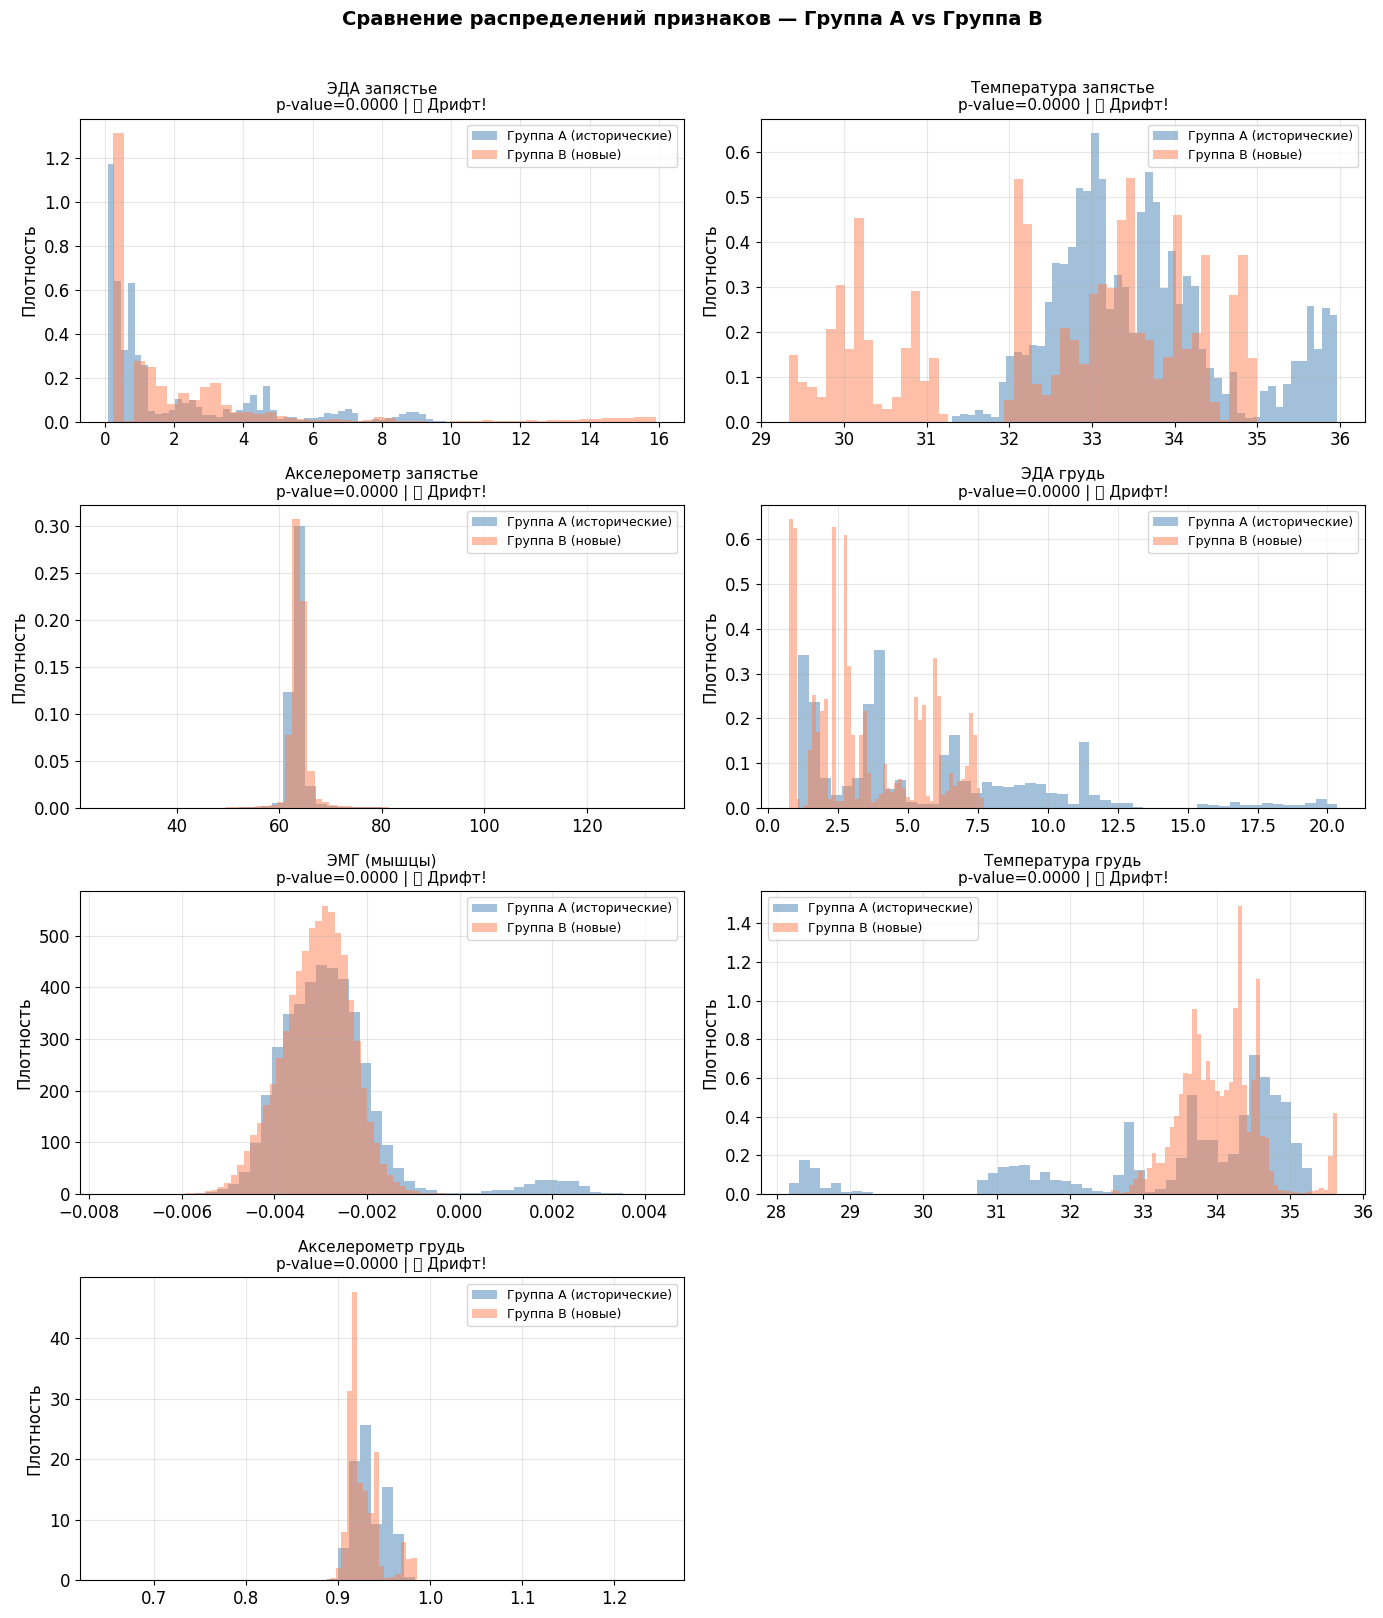

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, feat in enumerate(features):
    ax = axes[idx]
    
    ax.hist(group_a[feat], bins=50, alpha=0.5, 
            color='steelblue', label='Группа A (исторические)', density=True)
    ax.hist(group_b[feat], bins=50, alpha=0.5, 
            color='coral', label='Группа B (новые)', density=True)
    
    ks_stat, p_value = stats.ks_2samp(group_a[feat], group_b[feat])
    drift_label = '🔴 Дрифт!' if p_value < 0.05 else '🟢 Стабильно'
    
    ax.set_title(f"{ru_names[feat]}\np-value={p_value:.4f} | {drift_label}", fontsize=11)
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Убираем лишний subplot
axes[-1].set_visible(False)

plt.suptitle('Сравнение распределений признаков — Группа A vs Группа B', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Визуализация — KS статистика по признакам

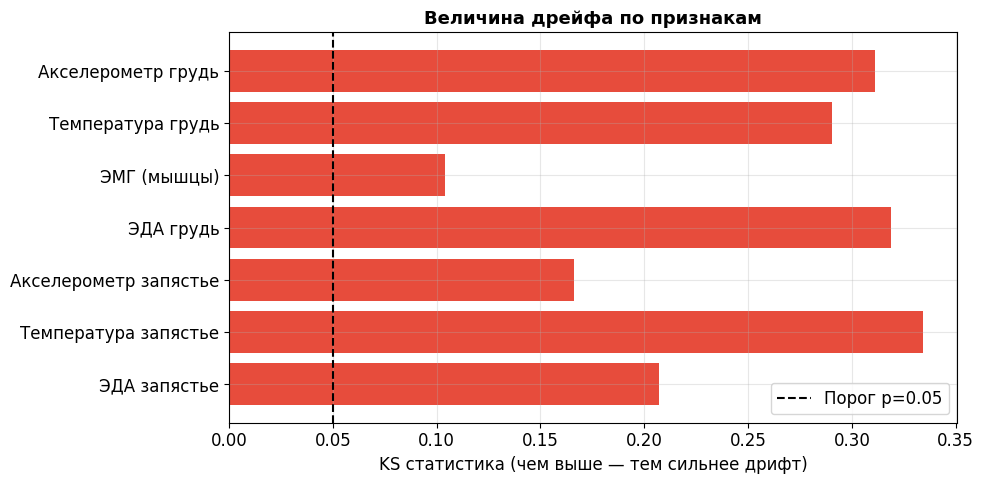

In [5]:
df_plot = df_results.copy()
df_plot['KS статистика'] = df_results['KS статистика']
df_plot['color'] = df_results['Дрифт'].apply(
    lambda x: '#e74c3c' if 'Да' in x else '#2ecc71'
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_plot['Признак'], df_plot['KS статистика'], 
               color=df_plot['color'])

ax.axvline(x=0.05, color='black', linestyle='--', 
           linewidth=1.5, label='Порог p=0.05')
ax.set_xlabel('KS статистика (чем выше — тем сильнее дрифт)')
ax.set_title('Величина дрейфа по признакам', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Итоги анализа стабильности

In [6]:
drift_count = df_results['Дрифт'].str.contains('Да').sum()
stable_count = len(df_results) - drift_count

print("=" * 50)
print("ИТОГИ АНАЛИЗА СТАБИЛЬНОСТИ ДАННЫХ")
print("=" * 50)
print(f"Всего признаков:      {len(df_results)}")
print(f"🔴 С дрифтом:         {drift_count}")
print(f"🟢 Стабильных:        {stable_count}")
print()
print("Признаки с дрифтом:")
for _, row in df_results[df_results['Дрифт'].str.contains('Да')].iterrows():
    print(f"  • {row['Признак']} — KS={row['KS статистика']}, p={row['p-value']}")

ИТОГИ АНАЛИЗА СТАБИЛЬНОСТИ ДАННЫХ
Всего признаков:      7
🔴 С дрифтом:         7
🟢 Стабильных:        0

Признаки с дрифтом:
  • ЭДА запястье — KS=0.207, p=0.0
  • Температура запястье — KS=0.3341, p=0.0
  • Акселерометр запястье — KS=0.1663, p=0.0
  • ЭДА грудь — KS=0.319, p=0.0
  • ЭМГ (мышцы) — KS=0.1039, p=0.0
  • Температура грудь — KS=0.2904, p=0.0
  • Акселерометр грудь — KS=0.311, p=0.0


---
## 7. Выводы

### Интерпретация результатов

Тест Колмогорова-Смирнова выявил признаки с значимым дрейфом распределений  
между группами участников.

### Причины дрифта в WESAD
Дрифт между группами объясняется **межличностной вариативностью** —  
у каждого человека своя базовая физиология:
- разный уровень потоотделения в покое
- разная базовая температура кожи  
- разные паттерны движения

### Что делать в продакшне
В реальной системе при обнаружении дрифта рекомендуется:
1. **Переобучить модель** на новых данных
2. **Персонализировать модель** под конкретного пользователя
3. **Установить пороги алертов** для автоматического мониторинга

### Ограничения
Поскольку WESAD не содержит временных меток по датам сбора,  
дрифт симулирован через разбиение по участникам.  
В реальной системе мониторинг проводится на временных рядах входящих данных.